# EV Charging Demand Prediction Using Random Forest

**Mini Project Notebook**

This notebook generates a synthetic EV charging demand dataset, trains a Random Forest Regressor, evaluates its performance, and analyzes feature importance.


## Abstract

The rapid adoption of Electric Vehicles (EVs) has created a need for efficient charging infrastructure planning and load management. This project uses a **Random Forest Regression** model to predict EV charging demand from temporal, environmental, infrastructure, socio-economic, and historical-usage features.

The model is evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

Feature importance is also examined to identify the strongest predictors of charging demand.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


## 1. Generate a Synthetic EV Charging Demand Dataset

In [2]:
np.random.seed(42)
n_samples = 2000

hour = np.random.randint(0, 24, n_samples)
day_of_week = np.random.randint(0, 7, n_samples)  # 0=Mon ... 6=Sun
is_weekend = (day_of_week >= 5).astype(int)
temperature = np.random.normal(22, 8, n_samples)  # deg C
num_stations = np.random.randint(1, 20, n_samples)  # chargers at location
distance_to_highway = np.random.uniform(0.1, 15, n_samples)  # km
avg_income_index = np.random.normal(100, 20, n_samples)  # relative income index
past_week_avg_demand = np.random.normal(15, 6, n_samples)

# Simulated ground-truth relationship (with noise) that a Random Forest
# can learn: demand peaks during morning/evening commute hours,
# increases with station count and nearby income, and drops on weekends.
base_demand = (
    10
    + 8 * np.exp(-((hour - 9) ** 2) / 8)  # morning peak
    + 10 * np.exp(-((hour - 18) ** 2) / 10)  # evening peak
    + 0.6 * num_stations
    - 0.3 * distance_to_highway
    + 0.05 * avg_income_index
    - 3 * is_weekend
    + 0.4 * past_week_avg_demand
    - 0.1 * np.abs(temperature - 20)
)

noise = np.random.normal(0, 3, n_samples)
demand = np.clip(base_demand + noise, 0, None)

df = pd.DataFrame({
    "hour": hour,
    "day_of_week": day_of_week,
    "is_weekend": is_weekend,
    "temperature_C": temperature,
    "num_stations": num_stations,
    "distance_to_highway_km": distance_to_highway,
    "avg_income_index": avg_income_index,
    "past_week_avg_demand": past_week_avg_demand,
    "charging_demand": demand
})

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2000, 9)


,hour,day_of_week,is_weekend,temperature_C,num_stations,distance_to_highway_km,avg_income_index,past_week_avg_demand,charging_demand
0,6,1,0,31.551650,19,4.637396,58.264964,12.169171,27.311561
1,19,3,0,19.304817,1,0.470407,88.741605,15.352519,27.585864
2,14,5,1,25.317588,12,0.158320,125.092727,2.551068,26.540950
3,10,6,1,33.935357,7,3.485394,111.249598,2.096854,23.124668
4,7,1,0,31.326448,4,6.155454,125.425725,26.862759,26.287493


## 2. Train / Test Split

In [3]:
X = df.drop(columns=["charging_demand"])
y = df["charging_demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


Training samples: 1600
Test samples: 400


## 3. Train Random Forest Regressor

In [4]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete.")


Random Forest training complete.


## 4. Evaluate the Model

In [5]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation on Test Set:")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")


Model Evaluation on Test Set:
MAE  : 2.935
RMSE : 3.646
R2   : 0.672


## 5. Feature Importance

In [6]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("Feature Importance:")
importance


Feature Importance:


num_stations              0.293043
hour                      0.230494
past_week_avg_demand      0.205607
distance_to_highway_km    0.102804
avg_income_index          0.072181
temperature_C             0.047397
day_of_week               0.037118
is_weekend                0.011357
dtype: float64

## 6. Visualizations

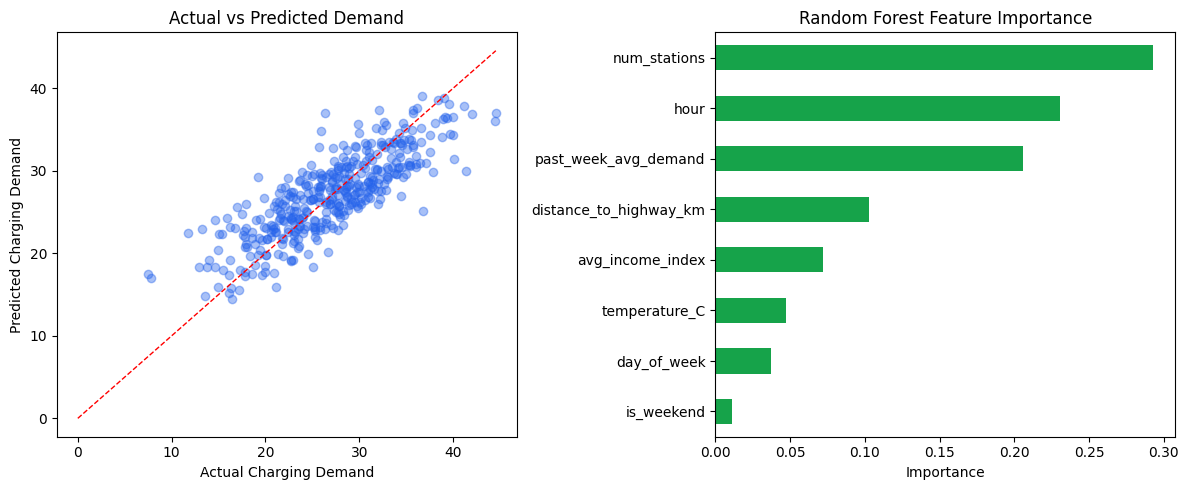

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color="#2563eb")
lims = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual Charging Demand")
axes[0].set_ylabel("Predicted Charging Demand")
axes[0].set_title("Actual vs Predicted Demand")

importance.plot(kind="barh", ax=axes[1], color="#16a34a")
axes[1].invert_yaxis()
axes[1].set_xlabel("Importance")
axes[1].set_title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


## Conclusion

The Random Forest model captures the main synthetic EV charging-demand patterns and allows the most influential predictors to be inspected through feature importance. In the project report, the strongest predictors are the **number of charging stations**, **hour of day**, and **past week's average demand**.
